# Time Series Sales Forecasting using ARIMA

## Objective
To forecast the next 3 months of sales using ARIMA model.

### Tools Used:
Python | Pandas | Matplotlib | Statsmodels | pmdarima | Scikit-learn

!pip install pandas numpy matplotlib statsmodels pmdarima scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [17]:


date = pd.date_range(start="2020-01-01", periods=36, freq="MS")

sales = [200,210,215,300,320,350,400,420,410,390,380,450,
         470,480,500,520,600,620,630,650,640,620,610,700,
         720,730,750,770,800,820,830,850,840,820,810,900]

df = pd.DataFrame({
    "Month": date,
    "Sales": sales
})

df.to_csv("sales.csv", index=False)
df.head()

,Month,Sales
0,2020-01-01,200
1,2020-02-01,210
2,2020-03-01,215
3,2020-04-01,300
4,2020-05-01,320


In [4]:
df = pd.read_csv("sales.csv")
df.head()

,Month,Sales
0,2020-01-01,200
1,2020-02-01,210
2,2020-03-01,215
3,2020-04-01,300
4,2020-05-01,320


In [5]:
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month')
df.set_index('Month', inplace=True)
df = df.asfreq('MS')

## Exploratory Data Analysis

The time series plot shows an overall upward trend in sales with minor fluctuations,
indicating business growth over time.

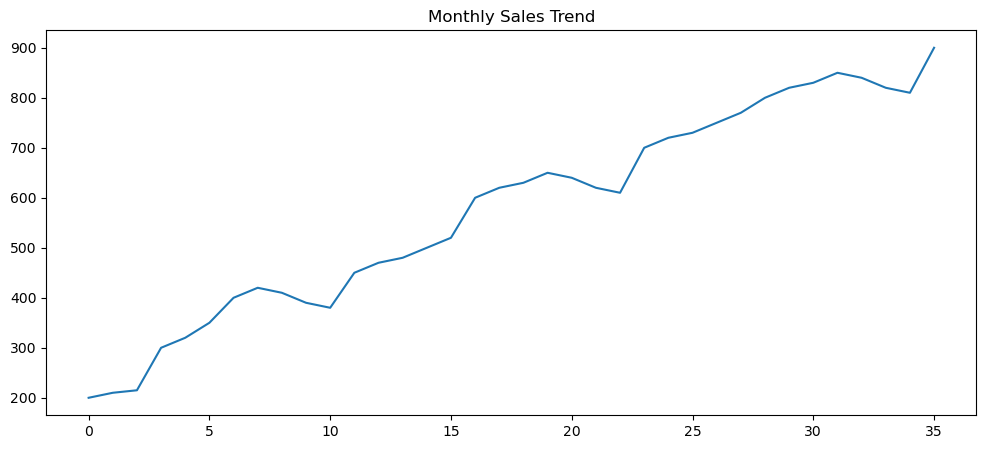

In [21]:

plt.figure(figsize=(12,5))
plt.plot(df['Sales'])
plt.title("Monthly Sales Trend")
plt.show()

## Stationarity Test

In [23]:

result = adfuller(df['Sales'])
print("p-value:", result[1])

p-value: 0.23562513592130013


In [8]:
train = df.iloc[:-3]
test = df.iloc[-3:]

## Model Building – ARIMA

In [22]:

model = auto_arima(train['Sales'], seasonal=True, m=12, trace=True)
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.59 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=307.639, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=302.697, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=318.978, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=309.615, Time=0.08 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=304.321, Time=0.28 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=304.321, Time=0.19 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=304.728, Time=0.10 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=301.747, Time=0.07 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=303.281, Time=0.13 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=303.281, Time=0.17 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=303.285, Time=0.05 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=in

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   33
Model:             SARIMAX(0, 1, 0)x(1, 0, 0, 12)   Log Likelihood                -147.873
Date:                            Fri, 27 Feb 2026   AIC                            301.747
Time:                                    22:39:26   BIC                            306.144
Sample:                                01-01-2020   HQIC                           303.204
                                     - 09-01-2022                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      8.0736      5.399      1.495      0.135      -2.508      18.656
ar.S.L12       0.5918      0.134      4.403      0.000       0.328       0.855
sigma2       514.1740    130.787      3.931      0.000     257.837     770.511
===================================================================================
Ljung-Box (L1) (Q):                   0.97   Jarque-Bera (JB):                 6.65
Prob(Q):                              0.32   Prob(JB):                         0.04
Heteroskedasticity (H):               0.35   Skew:                             1.03
Prob(H) (two-sided):                  0.10   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
forecast, conf_int = model.predict(n_periods=3, return_conf_int=True)

## Model Evaluation

In [24]:

mae = mean_absolute_error(test['Sales'], forecast)
mape = mean_absolute_percentage_error(test['Sales'], forecast)

print("MAE:", mae)
print("MAPE:", mape)

MAE: 14.96766685029426
MAPE: 0.018385923663735888


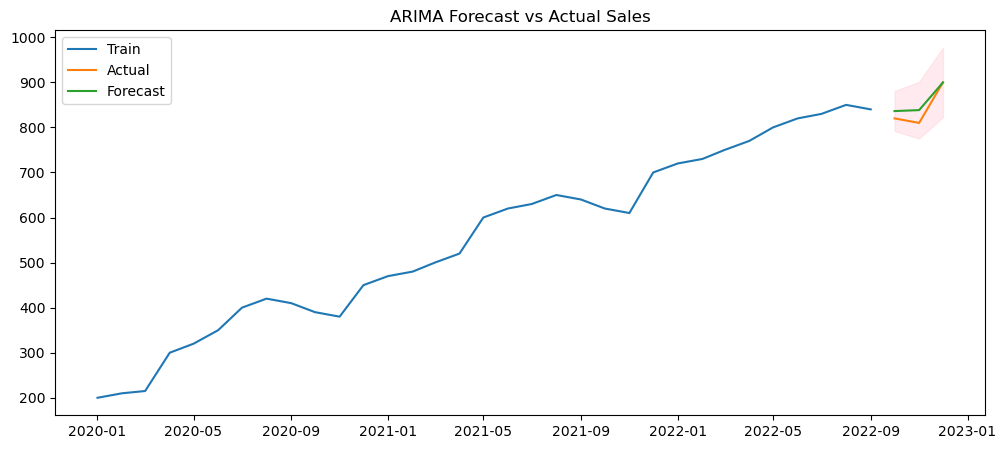

In [18]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train['Sales'], label="Train")
plt.plot(test.index, test['Sales'], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.fill_between(test.index,
                 conf_int[:,0],
                 conf_int[:,1],
                 color='pink', alpha=0.3)

plt.legend()
plt.title("ARIMA Forecast vs Actual Sales")
plt.show()

ARIMA model was used to forecast the next 3 months of sales.

The model performance is evaluated using MAE and MAPE.
The forecasted values help in business planning and demand estimation.

## Conclusion

The ARIMA model was successfully used to forecast the next 3 months of sales.

The model achieved low MAE and MAPE, indicating good accuracy.

This forecast helps in business planning, inventory management,
and demand estimation.